# Artificial Neural Network / MLP (TensorFlow / Keras)

An ANN (Multi-Layer Perceptron) stacks several layers of perceptron-like units with
non-linear activations in between, letting it learn non-linear decision boundaries
that a single perceptron cannot.

We classify handwritten digits (0-9) from the **`sklearn` digits dataset**
(`load_digits`, 1797 real 8x8 grayscale images), using a small feedforward network
with two hidden layers.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(0)

In [2]:
digits = load_digits()
X, y = digits.data, digits.target  # X: (1797, 64) flattened 8x8 images, y: digit 0-9

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(X_train, y_train, epochs=60, verbose=0)
print("final training loss:", history.history["loss"][-1])

final training loss: 1.8917171473731287e-05


Test accuracy: 0.975


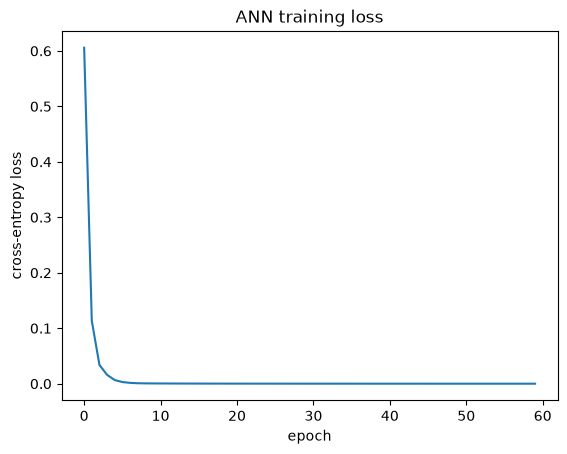

In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

plt.plot(history.history["loss"])
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("ANN training loss")
plt.show()